In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
import scipy.stats as stats

In [3]:
df = pd.read_csv('spotify_one_genre.csv')
df.head()

,artists,track_name,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity,title_size,duration,num_artists
0,!nvite,pagadoff,0,0.784,0.657,11,-7.591,0,0.348,0.332,0.00362,0.131,0.501,84.997,4,study,5,8,2.264333,1
1,!nvite,strolling,0,0.857,0.381,2,-12.755,1,0.192,0.666,0.01910,0.126,0.329,84.997,4,study,41,9,2.314583,1
2,"""Puppy Dog Pals"" Cast",Going on a Mission,0,0.629,0.776,7,-3.839,0,0.047,0.021,0.00000,0.093,0.957,93.937,3,children,55,18,0.635733,1
3,"""Puppy Dog Pals"" Cast",Puppy Dog Pals Main Title Theme,0,0.781,0.936,3,-4.709,1,0.202,0.171,0.00141,0.202,0.873,182.148,4,children,60,31,0.963150,1
4,"""Weird Al"" Yankovic","Amish Paradise (Parody of ""Gangsta's Paradise""...",0,0.728,0.448,8,-10.540,1,0.172,0.103,0.00000,0.267,0.483,80.902,4,comedy,58,57,3.382000,1


Проверка гипотез в данной работе производится на выбранном уровне значимости 5%.

## Гипотеза 1:

#### H0: мат ожидание индекса популярности треков жанра k-pop равно мат ожиаднию индекса популярности жанра metal;

#### H1: мат ожидание индекса популярности треков жанра k-pop НЕ равно мат ожиаднию индекса популярности жанра metal

Алгоритм:

1. Разделим данные на две выборки: треки с жанром k-pop и metal. Каждому треку присвоен только один жанр, следовательно, предполагается независимость выборок;

2. Между выборками есть дисбаланс: число треков жанра k-pop (766) больше числа треков жанра metal (147). В целом, по каждой группе, наблюдений достаточно.

3. Будет произведен t-test с расчетом p-value, t-stat. Также, по выборке будет оценена дисперсия. Выбран именно двухвыборочный ttest (двухсторонний), так как нет информации об истинных дисперсиях выборок из истинных распределений. 

In [19]:
df_kpop = df[df.track_genre == 'k-pop']
df_metal = df[df.track_genre == 'metal']

In [20]:
# число наблюдений в выборке pop
n_kpop = df_kpop.shape[0]
n_kpop

766

In [21]:
# число наблюдений в выборке metal
n_metal = df_metal.shape[0]
n_metal

147

In [7]:
def mean_test(mean, var, n, m, mu_0=0, 
                   alpha=0.05, margin=3):
    """
        Тест для равенства средних
    """
    
    t_obs = (mean - mu_0)/np.sqrt(var * (1/n + 1/m))
    

    p_value = 2 * (1 - stats.t.cdf(np.abs(t_obs), df = n + m - 2))
    t_crit = stats.t.ppf(1 - alpha/2, df = n + m - 2)
        
    statistics = ['-t_crit', 't_crit', '-t_obs', 't_obs']
    params = dict(zip(statistics, [(-t_crit, -0.6, -margin, -t_crit, 'b'), 
                                    (t_crit, 0.05, t_crit, margin, 'b'),
                                    (-t_obs, -0.6, -margin, -t_obs, 'r'), 
                                    (t_obs, 0.1, t_obs, margin, 'r')]))

    
    
    x = np.linspace(-margin, margin)
    pdf = stats.t.pdf(x, df = n + m - 2)

    plt.plot(x, pdf, color="black")
    plt.ylabel("$f(x)$", fontsize=16)
    plt.xlabel("$x$", fontsize=16)
    y_max = plt.ylim()[1]
    
    for i in range(len(statistics)):
        statistic, text_margin, left_bound, right_bound, color = params[statistics[i]]
        
        plt.axvline(statistic, color=color, linestyle="--", lw=2)
        h = 0.8 if statistics[i].split('_')[-1] == 'crit' else 0.6
        plt.text(statistic + text_margin, 
                 h*y_max, round(statistic, 2), color=color, fontsize=16)
        
        xq = np.linspace(left_bound, right_bound)
        yq = stats.t.pdf(xq, df = n + m - 2)
        plt.fill_between(xq, 0, yq, color=color, alpha=0.2)
    
    return p_value

In [22]:
alpha = 0.05  
kpop = df_kpop.popularity
metal = df_metal.popularity

total_mean = kpop.mean() - metal.mean() 
var_0 = ((n_kpop - 1) * kpop.var() + (n_metal - 1) * metal.var() )/ (n_metal + n_kpop - 2)
                                    
t_obs = total_mean/np.sqrt(var_0 * (1 / n_kpop + 1 / n_metal))    
t_crit = stats.t.ppf(1 - alpha/2, df = n_kpop + n_metal - 2) 

print(f'{t_obs:.3} попадает в ({-t_crit:.3} , {t_crit:.3}) => Нулевая гипотеза НЕ отвергается на уровне значимости 5%')

0.0206 попадает в (-1.96 , 1.96) => Нулевая гипотеза НЕ отвергается на уровне значимости 5%


0.9835625228247877

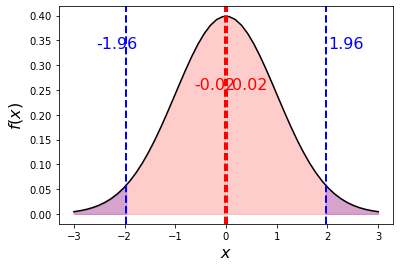

In [23]:
# p-value + график распределения, t-stat, ДИ
mean_test(total_mean, var_0, n_kpop, n_metal, alpha=0.05)

Рассчитанная t-статистика попадает внутрь критической области, а значение p-value значительно превосходит выбранный уровень значимости (0.05), соотвественно, нет оснований отвергать нулевую гипотезу, и математические ожидания индекса популярности треков жанра к-поп и метал можно считать равными. У жанра к-поп в последние годы стремительно растет аудитория, а метал уже долгие годы обладает обширной аудиторией по всему миру, поэтому полученные результаты, в целом, не противоречат реальности.

## Гипотеза 2:

#### H0: дисперсии индекса популярности треков жанров k-pop и metal равны

#### H1: дисперсии индекса популярности треков жанров k-pop и metal НЕ равны

Чтобы проверить гипотезу, будет рассчитана F-статистика (Тест Фишера). Для этого посчитаем выборочные дисперсии вручную.

In [26]:
kpop_var = kpop.var()
metal_var = metal.var()

F_obs = kpop_var / metal_var  
F_crit_right = stats.f.ppf(1 - alpha/2, n_kpop, n_metal) 
F_crit_left = stats.f.ppf(alpha/2, n_kpop, n_metal) 

print(f'{F_obs:.3} попадает в ({F_crit_left:.3} , {F_crit_right:.3}) => Нулевая гипотеза не отвергается на уровне значимости 5%')

0.8 попадает в (0.787 , 1.3) => Нулевая гипотеза не отвергается на уровне значимости 5%


F-stat не попадает в область отвержения нулевой гипотезы, следовательно, нет оснований отвергать нулевую гипотезу: дисперсии индекса популярности жанров k-pop и metal равны.
Оба жанра достаточно популярны, имеют широкую аудиторию, но при этом остаются специфичными. 

Как итог, основываясь на результатах тестирований на конкретных данных, нельзя отрицать, что распределения индекса популярности жанров k-pop и metal равны.

## Гипотеза 3:

#### H0: мат ожидание danceability у треков жанра pop равно мат ожиданию danceability у треков жанра metal 

#### H1: мат ожидание danceability у треков жанра pop БОЛЬШЕ, чем мат ожидание danceability у треков жанра metal 

Выборки также независимы.
Дисбаланс наблюдений уже не так ярко выражен: в жанре поп 306 треков. Для проверки данной гипотезы будет использован односторонний t-test (встроенные методы).

In [17]:
df_pop = df[df.track_genre == 'pop']
df_pop.shape[0]

306

In [27]:
from scipy.stats import ttest_ind

In [33]:
t_stat, p_val = ttest_ind(df_pop.danceability, df_metal.danceability, alternative = 'greater')
p_val < 0.05

True

In [34]:
print(f'p-value = {p_val:.3} < alpha = 0.05 => Нулевая гипотеза отвергается на уровне значимости 5%')

p-value = 2.25e-38 < alpha = 0.05 => Нулевая гипотеза отвергается на уровне значимости 5%


Нулевая гипотеза отвергнута, следовательно, мат ожидание dnceability у треков жанра pop действительно больше, чем у треков жанра metal, что соотносится с ранее изложенными предположениями.